## Practical session 4: Accelerated gradient descent and conjugate gradient


Today's session is dedicated to two first-order algorithms for unconstrained problems. The first is a faster variant of gradient descent, called accelerated gradient descent, and the other algorithm, called conjugate gradient descent, was originally designed for quadratic problems, but later extended for general non-linear problems.

### Accelerated gradient descent

When minimizing $f : \mathbb{R}^d \rightarrow \mathbb{R}$ on $\mathbb{R}^d$, gradient descent achieves a $\mathcal{O}(1 / k)$ global convergence rate if $f$ is convex and $\nabla f$ is Lipschitz. Actually, it can be shown that for such functions, a first-order method cannot achieve better rates than $\mathcal{O}(1 / k^2)$, which hints at the existence of faster first-order algorithms.

Accelerated gradient descent is an algorithm that achieves this $\mathcal{O}(1 / k^2)$ global convergence rates. It is sometimes called "Nesterov's method" from Y. Nesterov, who proved the $\mathcal{O}(1/k^2)$ limit, proposed the accelerated gradient descent algorithm, and shown that it achieved this rate.

The algorithm runs as follows: Initialize the algorithm with $x_0 \in \mathbb{R}^d$, $y_0 = x_0$, $\lambda_0 = 0$, and choose the step size $\tau > 0$. Then, at every iteration $k \in \mathbb{N}$, perform
\begin{align*}
    x_{k+1} &= y_k - \tau \nabla f(y_k)\\
    \lambda_{k+1} &= \frac{1 + \sqrt{1 + 4 \lambda_k^2}}{2}\\
    y_{k+1} &= x_{k+1} + \frac{\lambda_k - 1}{\lambda_{k+1}} (x_{k+1} - x_k).
\end{align*}

The intuition behind the performance of the accelerated gradient descent is rather unclear (let us mention for instance the link with the discretization of second-order differential equations).

> Implement the accelerated gradient descent algorithms in the file `algorithms.py`.

> Run the accelerated gradient descent algorithm on the objective function $f_1$ from `problem1.py`, starting at $x_0 = 0$, with $\tau = 10^{-3}$, $\texttt{iterMax} = 5000$, and $\texttt{prec} = 10^{-6}$. What do you observe on the shape of the curves $\{f(x_k)\}_{k\in\mathbb{N}}$ and $\{\| \nabla f(x_k)\| \}_{k \in \mathbb{N}}$?

In [1]:
from utils import *
import problem1 as pb1
from algorithms import *

------------------------------------
 Accelerated GD with constant step size
------------------------------------
START
FINISHED -- 1834 iterations -- 0.169485s -- final value: 0.000066 -- final gradient norm: 0.013190 




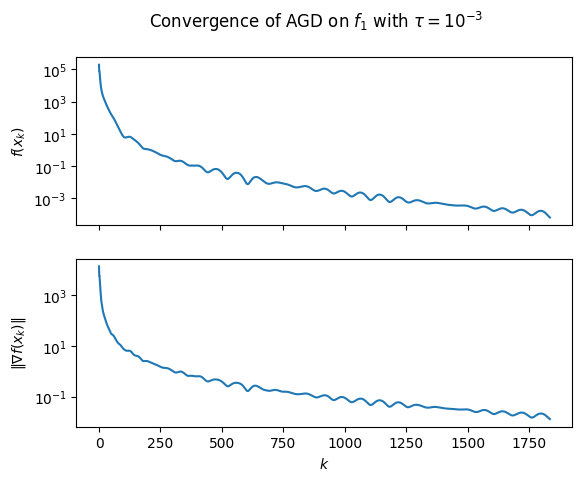

In [2]:
x_star, x_tab = GD_accelerated(pb1.f, pb1.grad_f, np.zeros(pb1.d), 0.001, 5000, 0.000001)
plot_obj_normGrad(x_tab, pb1.f, pb1.grad_f, r"Convergence of AGD on $f_1$ with $\tau = 10^{-3}$")

> Run the gradient descent algorithms in the same conditions. Which algorithm is faster?

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 4999 iterations -- 5.469974s -- final value: 0.001435 -- final gradient norm: 0.055388 




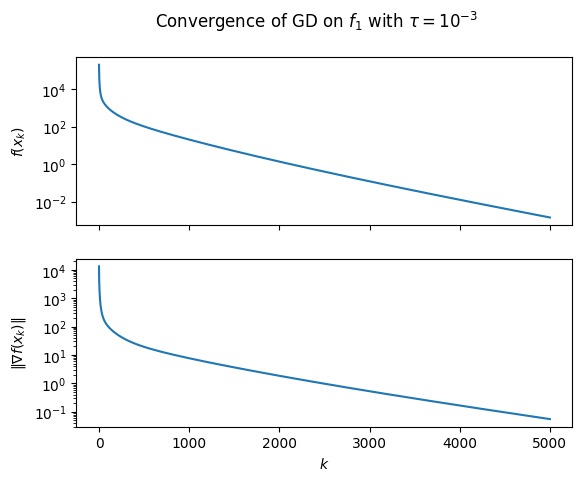

In [3]:
x_star, x_tab = GD(pb1.f, pb1.grad_f, np.zeros(pb1.d), 0.001, 5000, 0.000001)
plot_obj_normGrad(x_tab, pb1.f, pb1.grad_f, r"Convergence of GD on $f_1$ with $\tau = 10^{-3}$")

### Conjugate gradient

The conjugate gradient is an algorithm that is initially designed to minimize quadratic functions of the form $f(x) = \frac{1}{2}x^\top A x + b^\top x + c$ on $\mathbb{R}^d$ (with $A$ symmetric positive definite). The algorithm proceeds by iteratively constructing descent directions, such that at every iteration, the new descent direction is orthogonal to the subspace spanned by all the previous descent directions. Therefore, all the descent directions up to iteration $k \in \mathbb{N}$ form an orthogonal subspace of dimension $k$. This implies in particular that the algorithm terminates in at most $d$ iterations.

Initialize the algorithm with $x_0 \in \mathbb{R}^d$, $r_0 = - \nabla f(x_0) = -(A x_0 + b)$ and $d_0 = r_0$. Then, at iteration $k \in \mathbb{N}$, perform the following:
\begin{align*}
    \tau_k &= \frac{r_k^\top d_k}{d_k^\top A d_k}\\
    x_{k+1} &= x_k + \tau_k d_k\\
    r_{k+1} &= -(A x_{k+1} + b)\\
    \beta_k &= \frac{r_{k+1}^\top r_{k+1}}{r_k^\top r_k}\\
    d_{k+1} &= r_{k+1} + \beta_k d_k.
\end{align*}
As you can observe, the descent directions $d_k$ do not only depend on the current point, but are iteratively updated using the past history of the iterates. Remark also that no matrix is stored across iterations.

> Run the conjugate gradient algorithm on the objective function $f_1$ from `problem1.py`, starting at $x_0 = 0$ with $\texttt{iterMax} = 5000$, and $\texttt{prec} = 10^{-6}$. What do you observe?

In [4]:
from utils import *
import problem1 as pb1
from algorithms import *

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 104 iterations -- 0.002162s -- final value: 0.000008 -- final gradient norm: 0.012405 




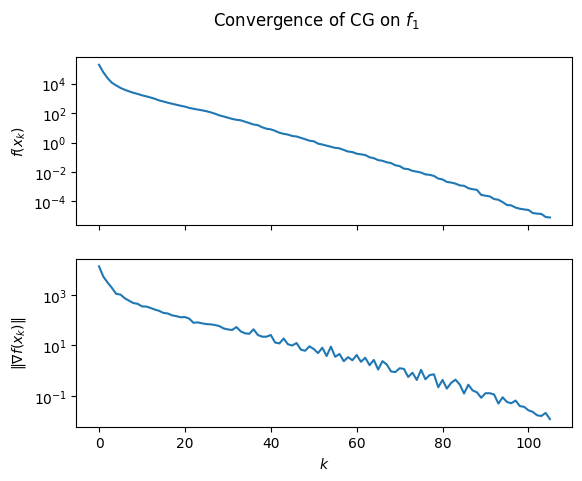

In [5]:
x_star, x_tab = CG_quadratic(pb1.A, pb1.b, pb1.f, pb1.grad_f, np.zeros(pb1.d), 5000, 0.000001)
plot_obj_normGrad(x_tab, pb1.f, pb1.grad_f, r"Convergence of CG on $f_1$")

### An inverse problem from signal processing

The field of inverse problems is concerned with the reconstruction of complex signals (e.g., images) denoted by $x$ from corrupted observations $\hat{y} = F(x) + n$ where $F$ is a transformation of the original signal (in the case of images, $F$ can be a blurring operator) and $n$ represents some noise corrupting the observation. Inverse problems are formulated as optimization problems of the form
$$
    \min_{x \in C} d(\hat{y} | F(x)) + r(x).
$$
This formulation implies that we are trying to find $x$ such that the transformed signal $F(x)$ is as close as possible to the observations $\hat{y}$, while achieving a low value of $r$ which is a penalization term. This formulation shares very close ties with maximum a posteriori estimation in Bayesian statistics.

Today, we consider a discretized signal reconstruction problem (from the paper *Nesterov's method in convex optimization*, N. J. Walkington, SIAM Review, 65(2), 2023). The signal $u : [0,1] \rightarrow \mathbb{R}$  can be reconstructed from the noisy signal $\hat{u} : [0,1] \rightarrow \mathbb{R}$ (here $F$ is the identity mapping) by minimizing
$$
    f(u) = \int_0^1 \frac{1}{2} | u(t) - \hat{u}(t) |^2 dt + \frac{\alpha}{\beta} \int_0^1 | u' |^\beta dt,
$$
where $\alpha, \beta$ are parameters of the formulation. The regularization term in the above enforces smooth reconstructed signals. Suppose that we have $N$ points $\{\hat{x}_i\}_{i=0}^N$ such that $\hat{x}_i = \hat{u}(ih)$ with $h = 1 / N$ for every $i \in \{ 1,\dots,N\}$. We will reconstruct $u$ by constructing $\{x_i\}_{n=0}^N$ such that $x_i \approx u(i h)$ for every $i \in \{ 1,\dots,N\}$. This leads (using trapezoid approximations) to the following problem:
$$
    \min_{x \in \mathbb{R}^{N+1}} \frac{h}{4}\left( (x_0 - \hat{x}_0)^2 + (x_N - \hat{x}_N)^2 \right) + \frac{h}{2} \sum_{i=1}^N (x_i - \hat{x}_i)^2 + \frac{\alpha h^{1-\beta}}{\beta} \sum_{i=0}^{N-1} (x_i - x_{i+1})^\beta.
$$
This problem with associated oracles (zero-th and first order oracles, as well as $A$, $b$, $c$ that are used to write the problem in canconical quadratic form when $\beta=2$) have been implemented in `problem2.py`.

> Compare the convergence speeds of the conjugate gradient algorithm, accelerated gradient descent ($\tau = 0.5$), and gradient descent with Wolfe line-search on `problem2` using $\alpha = 0.001$, $N=100$, $\beta = 2$, $\texttt{iterMax} = 2000$, and $\texttt{prec}=10^{-6}$.

In [6]:
from utils import *
from algorithms import *
import problem2 as pb2

------------------------------------
 Accelerated GD with constant step size
------------------------------------
START
FINISHED -- 1852 iterations -- 0.196967s -- final value: 0.006095 -- final gradient norm: 0.000000 




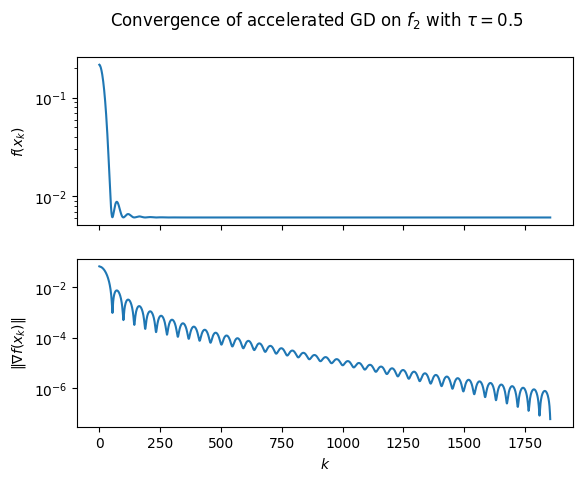

In [7]:
x_star_agd, x_tab = GD_accelerated(pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 0.5, 2000, 0.000001)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of accelerated GD on $f_2$ with $\tau = 0.5$")

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 41 iterations -- 0.004587s -- final value: 0.006095 -- final gradient norm: 0.000000 




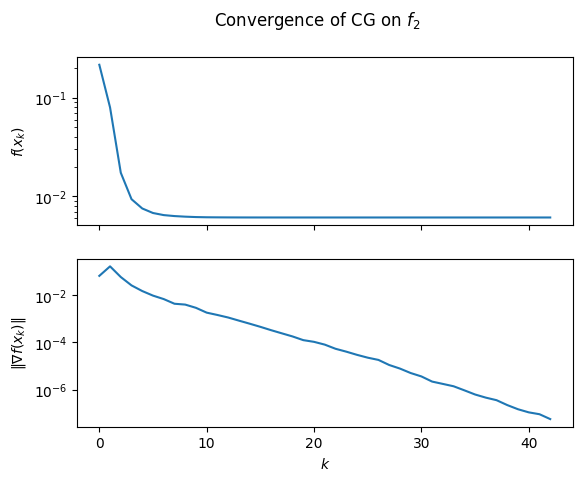

In [8]:
x_star_cg, x_tab = CG_quadratic(pb2.A, pb2.b, pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 2000, 0.000001)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of CG on $f_2$")

------------------------------------
 Gradient with Wolfe line search
------------------------------------
START
FINISHED -- 201 iterations -- 0.131825s -- final value: 0.006095 -- final gradient norm: 0.000000 




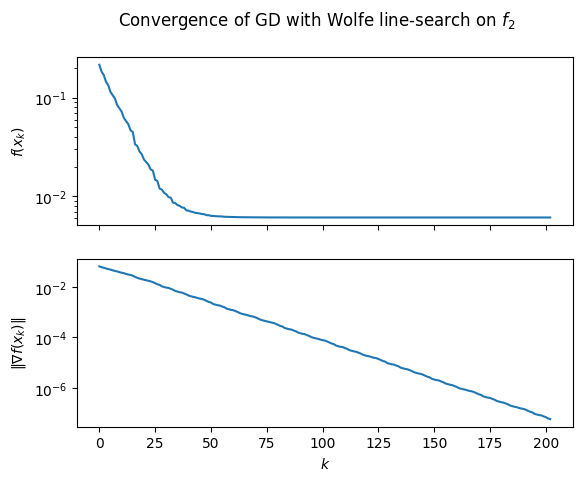

In [9]:
x_star_gdw, x_tab = GD_wolfe(pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 0.000001, 2000)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of GD with Wolfe line-search on $f_2$")

> How do the reconstructed solutions look like?

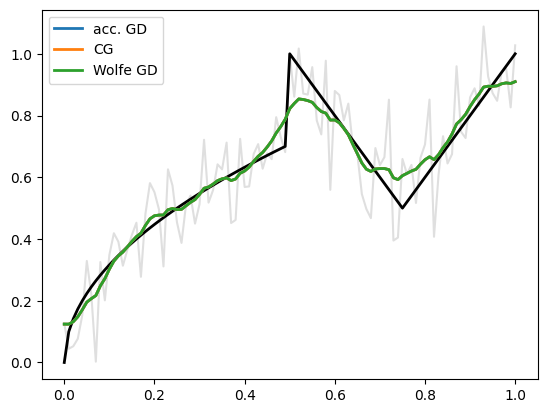

In [10]:
import matplotlib.pyplot as plt

plt.plot(np.linspace(0.0,1.0,pb2.N+1),pb2.x_hat, alpha=0.5, c='silver')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), [pb2.u(t) for t in np.linspace(0.0,1.0,pb2.N+1)],linewidth=2, c='k')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_agd, linewidth=2, label='acc. GD')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_cg, linewidth=2, label='CG')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_gdw, linewidth=2, label='Wolfe GD')
plt.legend()

### To go further: Influence of the parameters on the reconstruction problem

Of course, the quality of the reconstructed solution depends on data available, that is $\hat{x}$, and on the choice of hyper-parameters in our inverse problems. In particular, the number $N$ of sampled values imapcts the reconstruction as well as the dimension and conditionning of the optimization problem, while the choice of $\alpha$ impacts the strength of the regularization.

> Perform the same analysis as before with $N = 500$.

------------------------------------
 Accelerated GD with constant step size
------------------------------------
START
FINISHED -- 1852 iterations -- 0.197514s -- final value: 0.006095 -- final gradient norm: 0.000000 




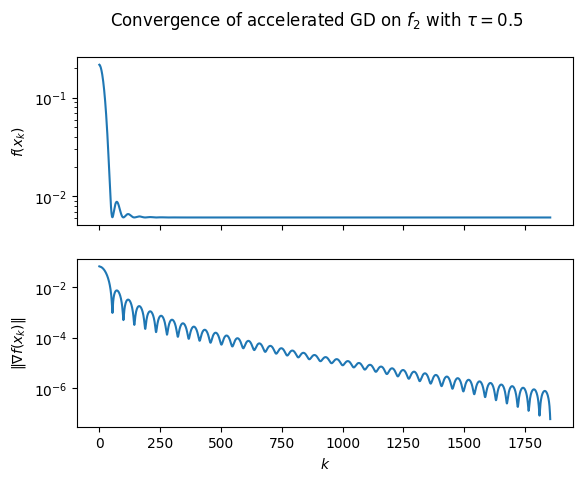

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 41 iterations -- 0.003983s -- final value: 0.006095 -- final gradient norm: 0.000000 




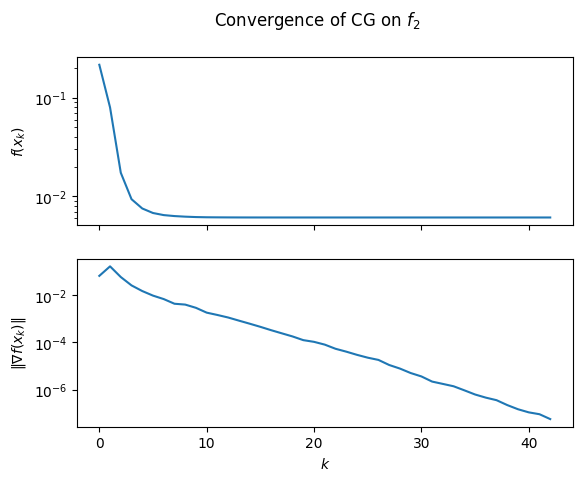

------------------------------------
 Gradient with Wolfe line search
------------------------------------
START
FINISHED -- 201 iterations -- 0.133480s -- final value: 0.006095 -- final gradient norm: 0.000000 




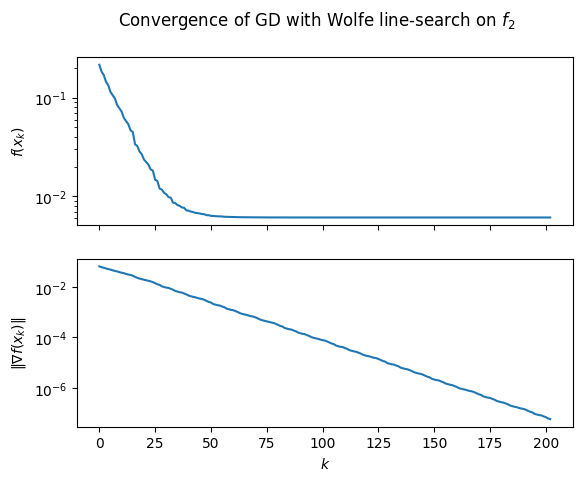

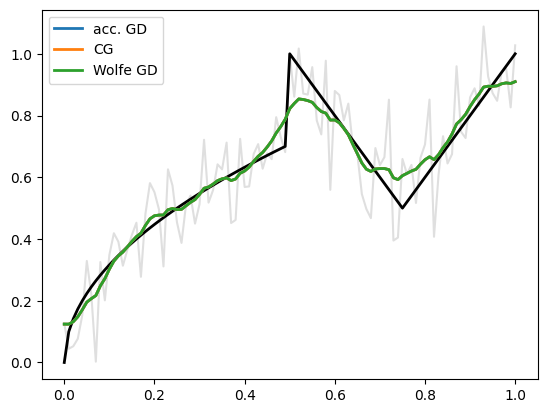

In [11]:
from utils import *
from algorithms import *
import problem2 as pb2

x_star_agd, x_tab = GD_accelerated(pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 0.5, 2000, 0.000001)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of accelerated GD on $f_2$ with $\tau = 0.5$")

x_star_cg, x_tab = CG_quadratic(pb2.A, pb2.b, pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 2000, 0.000001)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of CG on $f_2$")

x_star_gdw, x_tab = GD_wolfe(pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 0.000001, 2000)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of GD with Wolfe line-search on $f_2$")

plt.plot(np.linspace(0.0,1.0,pb2.N+1),pb2.x_hat, alpha=0.5, c='silver')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), [pb2.u(t) for t in np.linspace(0.0,1.0,pb2.N+1)],linewidth=2, c='k')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_agd, linewidth=2, label='acc. GD')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_cg, linewidth=2, label='CG')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_gdw, linewidth=2, label='Wolfe GD')
plt.legend()

> Come back to $N=100$ and try setting $\alpha=0$. What happens?

------------------------------------
 Accelerated GD with constant step size
------------------------------------
START
FINISHED -- 1852 iterations -- 0.206467s -- final value: 0.006095 -- final gradient norm: 0.000000 




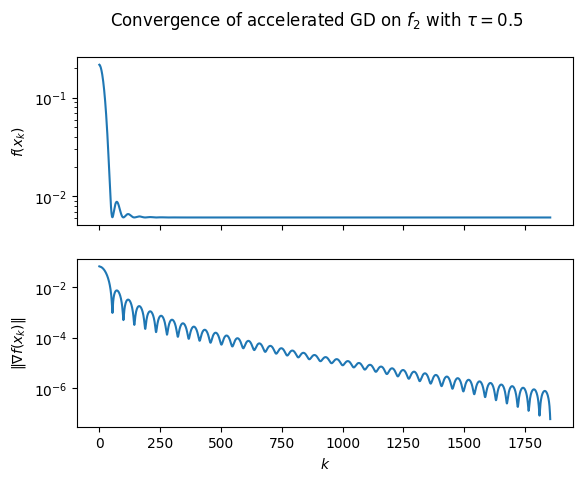

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 41 iterations -- 0.005310s -- final value: 0.006095 -- final gradient norm: 0.000000 




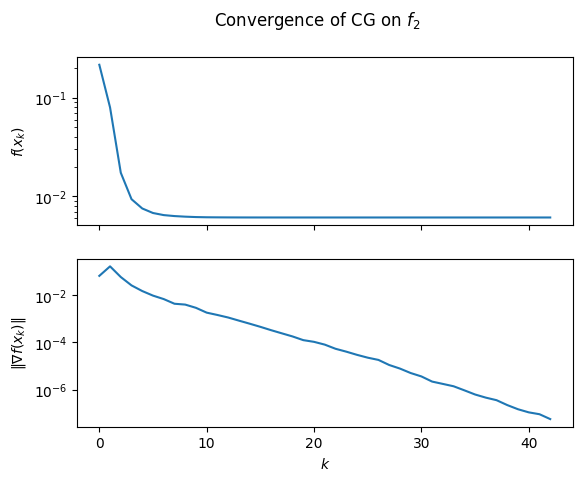

------------------------------------
 Gradient with Wolfe line search
------------------------------------
START
FINISHED -- 201 iterations -- 0.131164s -- final value: 0.006095 -- final gradient norm: 0.000000 




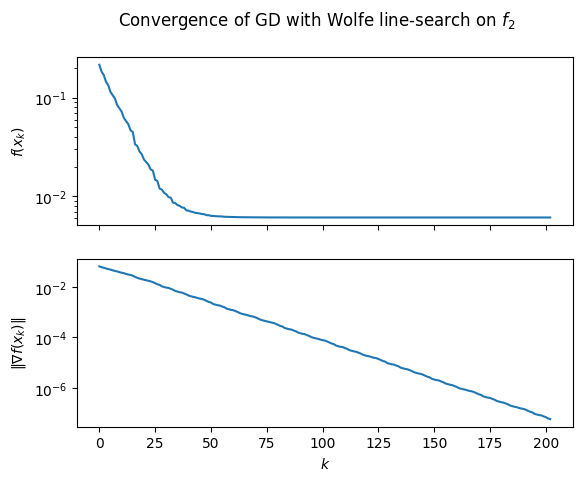

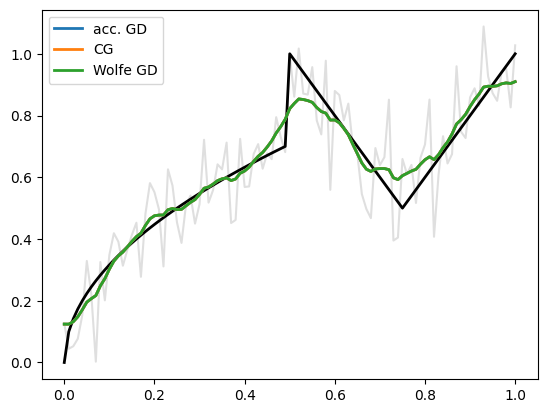

In [12]:
from utils import *
from algorithms import *
import problem2 as pb2

x_star_agd, x_tab = GD_accelerated(pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 0.5, 2000, 0.000001)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of accelerated GD on $f_2$ with $\tau = 0.5$")

x_star_cg, x_tab = CG_quadratic(pb2.A, pb2.b, pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 2000, 0.000001)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of CG on $f_2$")

x_star_gdw, x_tab = GD_wolfe(pb2.f, pb2.grad_f, np.zeros(pb2.N+1), 0.000001, 2000)
plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, r"Convergence of GD with Wolfe line-search on $f_2$")

plt.plot(np.linspace(0.0,1.0,pb2.N+1),pb2.x_hat, alpha=0.5, c='silver')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), [pb2.u(t) for t in np.linspace(0.0,1.0,pb2.N+1)],linewidth=2, c='k')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_agd, linewidth=2, label='acc. GD')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_cg, linewidth=2, label='CG')
plt.plot(np.linspace(0.0,1.0,pb2.N+1), x_star_gdw, linewidth=2, label='Wolfe GD')
plt.legend()

### To go further: Non-linear conjugate gradient algorithm

Although the conjugate gradient algorithm is designed for quadratic functions (it uses the optimal step size for instance) and enjoys very nice properties in this case (finite teermination), it can be extended to handle general non-linear objective functions. We now describe this algorithm.

Initialize the algorithm with $x_0 \in \mathbb{R}^d$, $r_0 = - \nabla f(x_0) = -\nabla f(x_0)$ and $d_0 = r_0$. Then, at iteration $k \in \mathbb{N}$, perform the following:
\begin{align*}
    \tau_k &\text{ is sought by a line-search with descent direction } d_k\\
    x_{k+1} &= x_k + \tau_k d_k\\
    r_{k+1} &= -\nabla f(x_{k+1})\\
    \beta_k &= \max \left( \frac{r_{k+1}^\top (r_{k+1} - r_k)}{r_k^\top r_k}, 0 \right)\\
    d_{k+1} &= r_{k+1} + \beta_k d_k.
\end{align*}

Compared with the conjugate gradient for conjugate objectives, this algorithm uses line-search to find the step sizes (indeed, optimal line-search is not available outside of quadratic problems), replaces the quantities $A x_k + b$ by $\nabla f(x_k)$, and computes the factors $\beta_k$ in a slightly different way. Without the max, this formula is called the Polyak-Ribières (PR) formula, while the other one is called the Fletcher-Reeves (FR) formula. The FR formula enjoys better theoretical properties, while the PR formula is known to be better in practice. The additional maximum step is also known to improve the performance in practice, as the descent directions are sometimes "refreshed".

> Implement the non-linear conjugate gradient algorithm, and run it on `problem1` with the line-search of your choice.

------------------------------------
 CG for quadratic objective 
------------------------------------
START
FINISHED -- 242 iterations -- 0.028588s -- final value: 0.000029 -- final gradient norm: 0.011927 




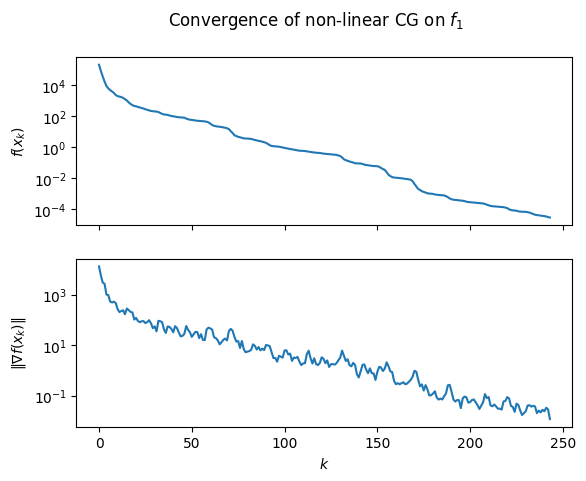

In [13]:
x_star, x_tab = CG_nonLinear(pb1.f, pb1.grad_f, np.zeros(pb1.d), 5000, 0.000001, 1.0, 0.5, 0.5)
plot_obj_normGrad(x_tab, pb1.f, pb1.grad_f, r"Convergence of non-linear CG on $f_1$")